# GateKeeper Model - Exploratory Data Analysis (EDA)
This notebook performs EDA on the Gatekeeper dataset to understand the image structure, class distribution, and properties before training the lightweight MobileNetV2 binary classification safeguard.

In [3]:
import os
import glob
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

%matplotlib inline
sns.set_theme(style="whitegrid")

## 1. Dataset Paths & Structure

In [13]:
#BASE_DIR = r"C:\Users\60122\OneDrive\Desktop\fyp_experiment\Final_year_project\ml_workflow\data\Gate_Keep"
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), "data", "Gate_Keep"))
TRAIN_DIR = "/workspaces/gate_keep/FinalYearProject/ml_workflow/data/Gate_Keep/train"
VAL_DIR   = "/workspaces/gate_keep/FinalYearProject/ml_workflow/data/Gate_Keep/validation"

CLASSES = ["knee", "not_knee"]

print(f"Training directory: {TRAIN_DIR}")
print(f"Validation directory: {VAL_DIR}")

Training directory: /workspaces/gate_keep/FinalYearProject/ml_workflow/data/Gate_Keep/train
Validation directory: /workspaces/gate_keep/FinalYearProject/ml_workflow/data/Gate_Keep/validation


## 2. Class Distribution

In [14]:
def count_images(directory, classes):
    counts = {}
    for cls in classes:
        path = os.path.join(directory, cls)
        if os.path.exists(path):
            num_images = len([f for f in os.listdir(path) if f.lower().endswith((".png", ".jpg", ".jpeg", ".bmp"))])
            counts[cls] = num_images
        else:
            counts[cls] = 0
    return counts

train_counts = count_images(TRAIN_DIR, CLASSES)
val_counts = count_images(VAL_DIR, CLASSES)

df_counts = pd.DataFrame({
    "Train": train_counts,
    "Validation": val_counts
}).T

display(df_counts)

,knee,not_knee
Train,845,1796
Validation,50,50


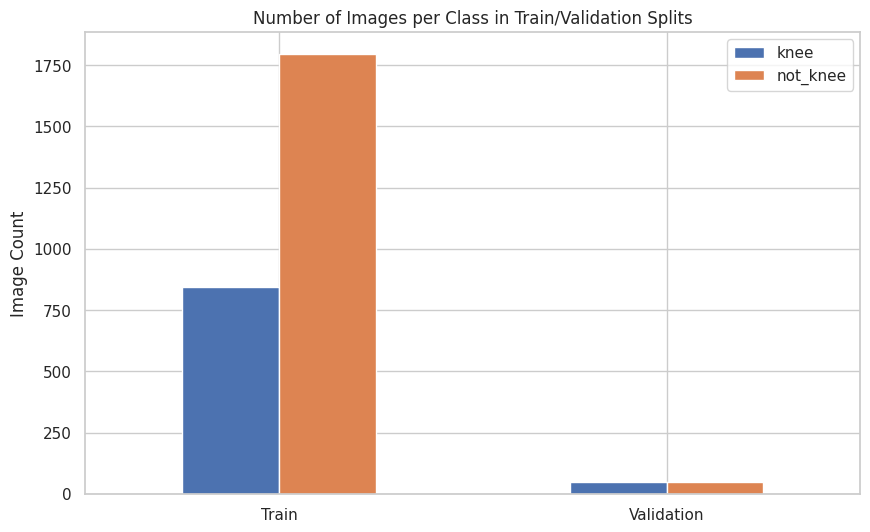

In [15]:
df_counts.plot(kind="bar", figsize=(10, 6))
plt.title("Number of Images per Class in Train/Validation Splits")
plt.ylabel("Image Count")
plt.xticks(rotation=0)
plt.show()

## 3. Visualizing Sample Images

Training Samples:


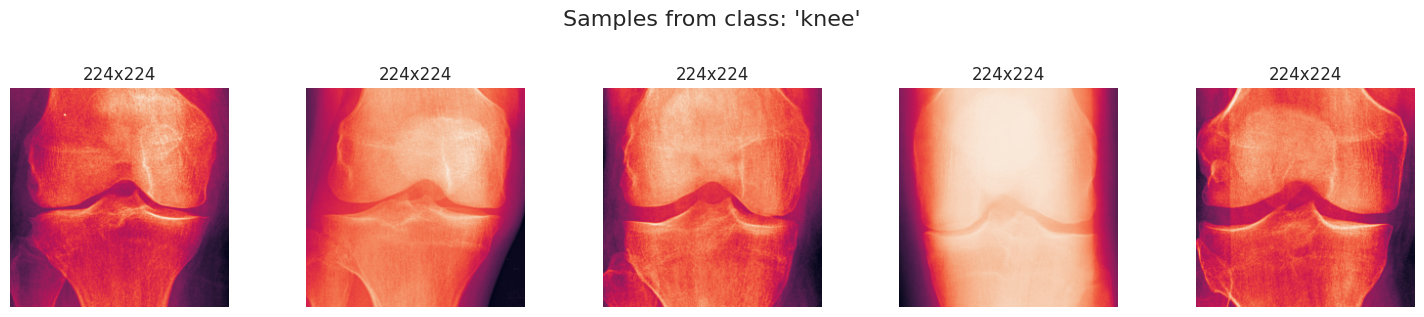

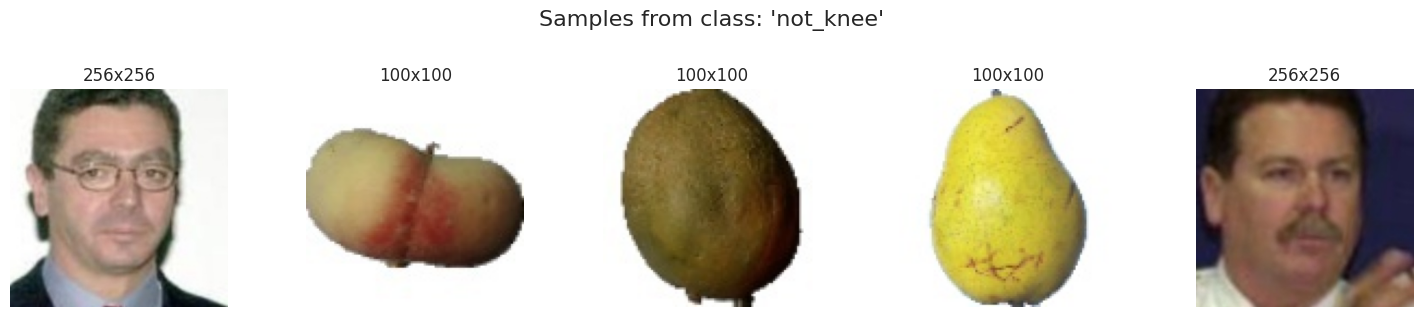

In [16]:
def plot_samples(directory, cls, num_samples=5):
    path = os.path.join(directory, cls)
    if not os.path.exists(path):
        print(f"Path {path} does not exist.")
        return
    
    images = [f for f in os.listdir(path) if f.lower().endswith((".png", ".jpg", ".jpeg", ".bmp"))]
    if len(images) == 0:
        print(f"No images found in {path}")
        return
        
    samples = random.sample(images, min(num_samples, len(images)))
    
    fig, axes = plt.subplots(1, num_samples, figsize=(15, 3))
    fig.suptitle(f"Samples from class: '{cls}'", fontsize=16, y=1.05)
    for img_name, ax in zip(samples, axes):
        img_path = os.path.join(path, img_name)
        img = Image.open(img_path)
        ax.imshow(img)
        ax.axis("off")
        ax.set_title(f"{img.size[0]}x{img.size[1]}")
    plt.tight_layout()
    plt.show()

print("Training Samples:")
for cls in CLASSES:
    plot_samples(TRAIN_DIR, cls)

## 4. Image Property Analysis (Dimensions & Aspect Ratios)

In [17]:
def collect_image_properties(directory, classes, max_samples=500):
    properties = []
    for cls in classes:
        path = os.path.join(directory, cls)
        if os.path.exists(path):
            images = [f for f in os.listdir(path) if f.lower().endswith((".png", ".jpg", ".jpeg", ".bmp"))]
            if len(images) > max_samples:
                images = random.sample(images, max_samples)
                
            for img_name in images:
                img_path = os.path.join(path, img_name)
                try:
                    with Image.open(img_path) as img:
                        w, h = img.size
                        properties.append({
                            "class": cls,
                            "width": w,
                            "height": h,
                            "aspect_ratio": w / h
                        })
                except Exception as e:
                    pass
    return pd.DataFrame(properties)

print("Analyzing image dimensions in the training set...")
df_props = collect_image_properties(TRAIN_DIR, CLASSES)
if not df_props.empty:
    display(df_props.groupby("class").agg(["mean", "min", "max", "std"]))
else:
    print("No images found for dimensions analysis.")

Analyzing image dimensions in the training set...


width                          height                        \
             mean  min   max         std     mean  min  max         std   
class                                                                     
knee      224.000  224   224    0.000000  224.000  224  224    0.000000   
not_knee  223.204   51  1042  134.682728  206.056   50  946  123.000012   

         aspect_ratio                                
                 mean       min       max       std  
class                                                
knee         1.000000  1.000000  1.000000  0.000000  
not_knee     1.172412  0.354633  5.460317  0.570572

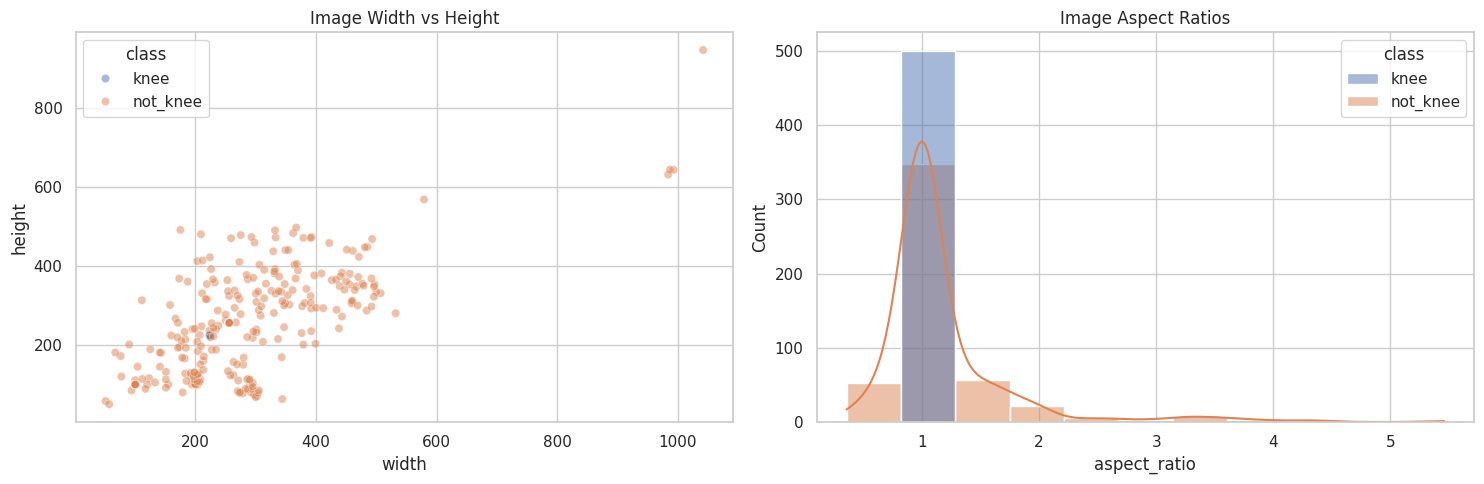

In [18]:
if not df_props.empty:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    sns.scatterplot(data=df_props, x="width", y="height", hue="class", alpha=0.5, ax=axes[0])
    axes[0].set_title("Image Width vs Height")
    
    sns.histplot(data=df_props, x="aspect_ratio", hue="class", kde=True, ax=axes[1])
    axes[1].set_title("Image Aspect Ratios")
    
    plt.tight_layout()
    plt.show()

## 5. Handling Class Imbalance

If the dataset is heavily imbalanced, we can use **Class Weights** during training to penalize the model more for missing the minority class. Below is the code to automatically calculate these weights.

In [19]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Create a list of all labels in the training set based on our counts
y_train = []
for cls, count in train_counts.items():
    y_train.extend([cls] * count)

if len(y_train) > 0:
    # Calculate class weights
    class_weights = compute_class_weight(
        class_weight='balanced',
        classes=np.unique(y_train),
        y=y_train
    )
    
    # Map weights to class indices (alphabetical order by default in Keras ImageFolder)
    class_labels = sorted(list(train_counts.keys()))
    weight_dict = {i: weight for i, weight in enumerate(class_weights)}
    
    print("Class Labels Indexing:", {i: label for i, label in enumerate(class_labels)})
    print("Computed Class Weights for Training:", weight_dict)
    
    # weight_dict can be passed directly to model.fit(..., class_weight=weight_dict)
else:
    print("No training data found to compute weights.")

Class Labels Indexing: {0: 'knee', 1: 'not_knee'}
Computed Class Weights for Training: {0: 1.5627218934911242, 1: 0.7352449888641426}


## 6. Data Augmentation Setup (TensorFlow/Keras Example)

If one class has significantly fewer images, you can apply heavy augmentation to the whole dataset to prevent overfitting and improve generalization.

In [20]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define an augmentation strategy suitable for Out-of-Distribution and Knee images
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Validation data should only be rescaled, NEVER augmented
val_datagen = ImageDataGenerator(rescale=1./255)

print("ImageDataGenerators are ready to be hooked up to flow_from_directory() for MobileNetV2!")

2026-06-09 07:17:43.052717: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-09 07:17:43.179036: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8473] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-09 07:17:43.217692: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1471] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-09 07:17:43.422990: I tensorflow/core/platform/cpu_feature_guard.cc:211] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX, in other operations, rebuild TensorFlow with the appropriate compiler flags.


ImageDataGenerators are ready to be hooked up to flow_from_directory() for MobileNetV2!


## 7. Conclusion & Next Steps

Based on the analysis above, we should verify:
- **Class Balance:** Are the `knee` and `not_knee` counts heavily imbalanced? If yes, we may need class weighting or augmentation for `not_knee`.
- **Resolution Matching:** MobileNetV2 typically expects `224x224` resolution. The scatter plot above will help inform if padding or just pure resizing is better suited for these OOD images.